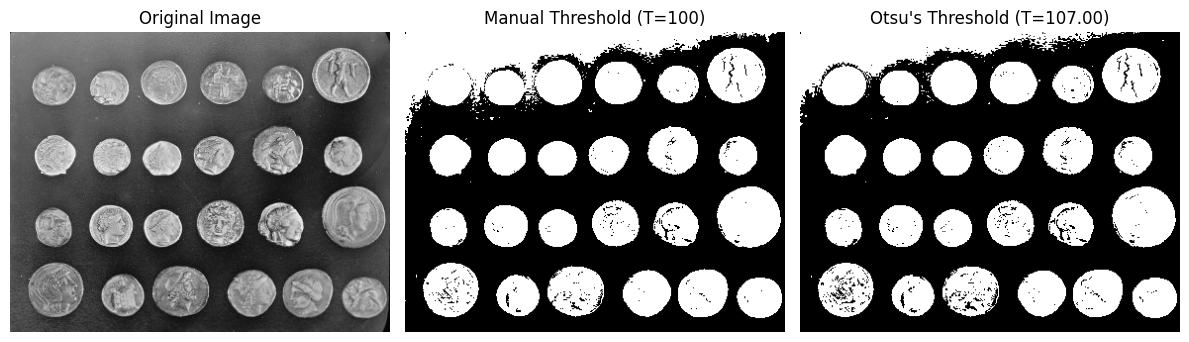

Nilai threshold Otsu yang ditemukan: 107


In [2]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. Memuat citra (contoh: coins)
image_coins = data.coins() # Citra sudah grayscale

# 2. Thresholding Global (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

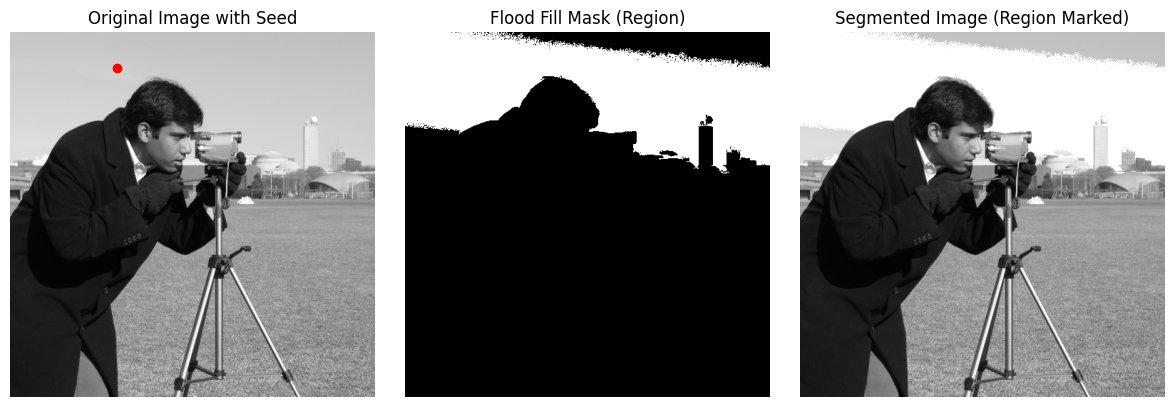

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misal, kita pilih titik di area langit (misal, koordinat y=50, x=150)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diisinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255 # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro') # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

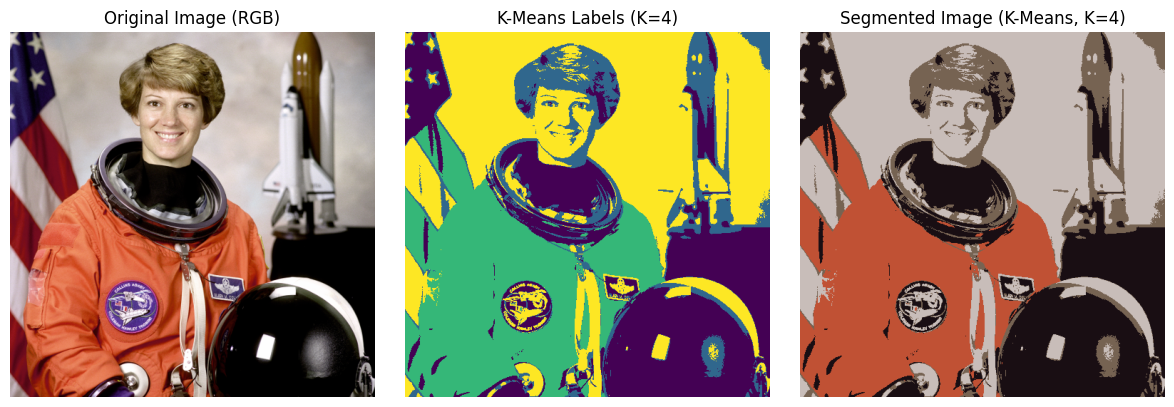

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()
# Konversi ke float untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra menjadi array piksel [jumlah_piksel, jumlah_fitur]
# Fitur bisa RGB atau Lab. Ruang warna Lab seringkali lebih baik untukpersepsi warna.
# Konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
# Tentukan jumlah klaster (segmen) yang diinginkan, misal K=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10) #n_init='auto' jika versi sklearn baru
# Hiding FutureWarnings related to default value of n_init
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra tersegmentasi (warnai setiap segmen dengan warna rata-rata klaster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    # Dapatkan piksel yang termasuk klaster k
    cluster_pixels = (pixel_labels == k)
    # Isi piksel tersebut di citra baru dengan warna pusat klaster k
    # Perlu reshape kembali cluster_pixels ke bentuk citra
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB untuk ditampilkan
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Menampilkan label klaster
ax[1].imshow(segmented_labels, cmap='viridis') # cmap bisa diganti
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Menampilkan citra hasil segmentasi K-Means
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

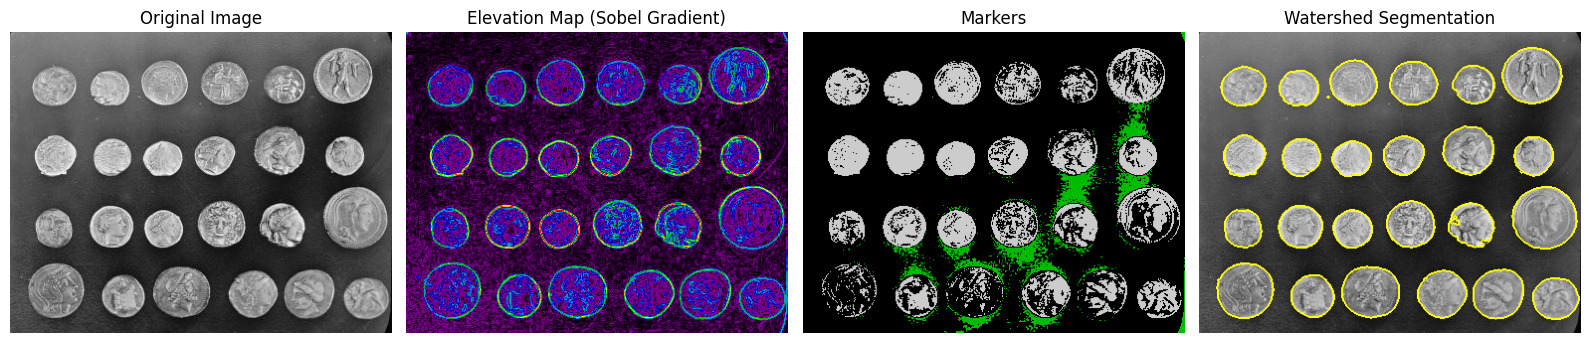

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker (penanda awal untuk setiap cekungan/objek)
# Kita bisa menggunakan thresholding untuk mendapatkan marker kasar
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1 # Marker untuk latar belakang
markers[image_coins > 150] = 2 # Marker untuk objek (koin)

# Atau gunakan marker dari local maxima (lebih canggih)
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi untuk visualisasi
segmented_colored = segmentation.mark_boundaries(image_coins,segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True,sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

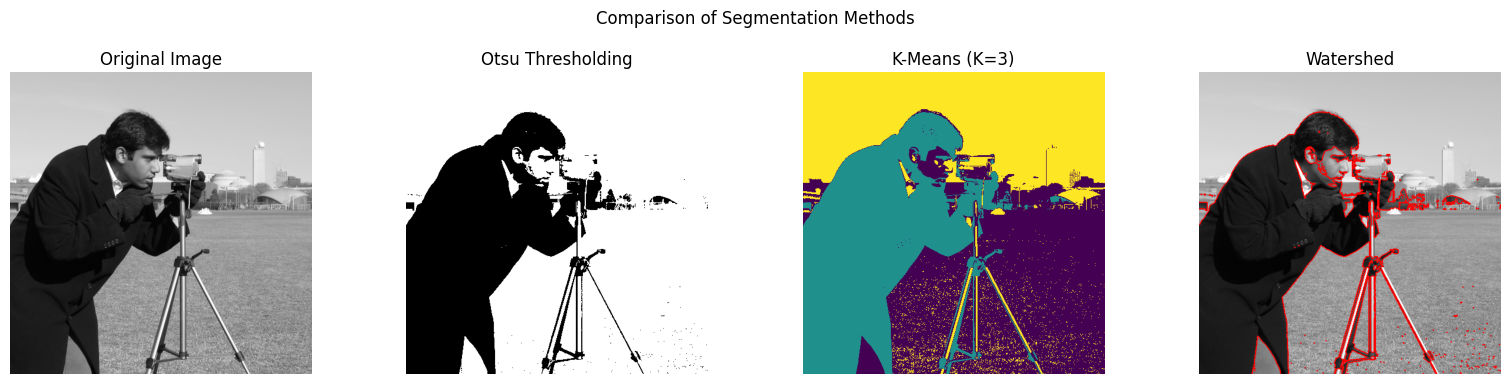

In [13]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan (misal: camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Lakukan beberapa metode segmentasi
# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
# Reshape untuk K-Means (1 fitur: intensitas)
rows, cols = image.shape


pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis') # Gunakan cmap
# berbeda untuk label
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Gunakan mark_boundaries untuk Watershed agar lebih jelas
segmented_watershed_colored = segmentation.mark_boundaries(image_float,
segmentation_watershed, color=(1,0,0)) # Batas merah
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

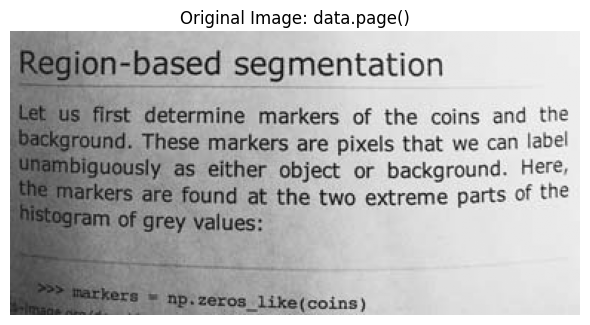

In [14]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.morphology import disk
import numpy as np

# 1. Memuat citra data.page()
image_page = data.page()

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(image_page, cmap=plt.cm.gray)
ax.set_title('Original Image: data.page()')
ax.axis('off')
plt.tight_layout()
plt.show()

### Thresholding Otsu pada `data.page()`

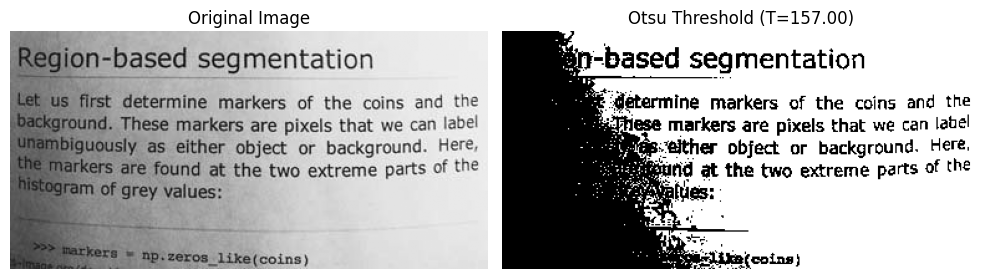

Nilai threshold Otsu untuk data.page(): 157.00


In [15]:
# 2. Thresholding Otsu
thresh_otsu_page = filters.threshold_otsu(image_page)
binary_otsu_page = image_page > thresh_otsu_page

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu_page, cmap=plt.cm.gray)
ax[1].set_title(f'Otsu Threshold (T={thresh_otsu_page:.2f})')
ax[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Nilai threshold Otsu untuk data.page(): {thresh_otsu_page:.2f}")

### Thresholding Adaptif Lokal (`threshold_local`)

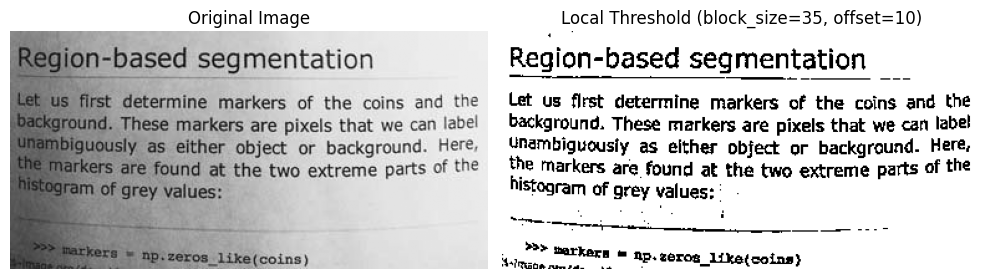

In [16]:
# 3. Thresholding Lokal Adaptif (threshold_local)
# block_size = ukuran jendela di sekitar piksel untuk menghitung ambang batas lokal
# offset = konstanta yang dikurangi dari rata-rata lokal untuk mendapatkan ambang batas
block_size = 35 # Contoh ukuran blok, bisa disesuaikan
local_thresh = filters.threshold_local(image_page, block_size, offset=10)
binary_local = image_page > local_thresh

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_local, cmap=plt.cm.gray)
ax[1].set_title(f'Local Threshold (block_size={block_size}, offset=10)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

### Thresholding Yen (`threshold_yen`)

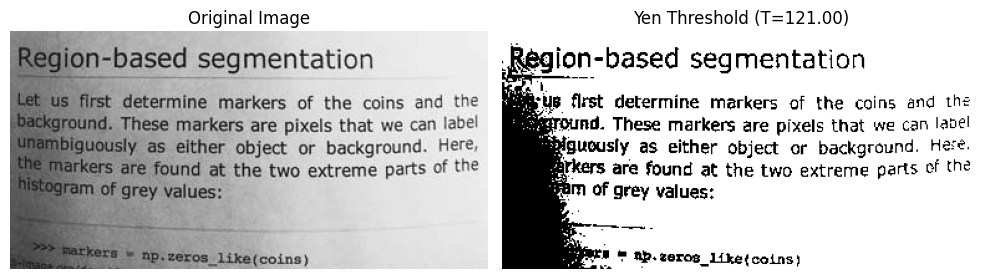

Nilai threshold Yen untuk data.page(): 121.00


In [17]:
# 4. Thresholding Yen
thresh_yen_page = filters.threshold_yen(image_page)
binary_yen_page = image_page > thresh_yen_page

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_yen_page, cmap=plt.cm.gray)
ax[1].set_title(f'Yen Threshold (T={thresh_yen_page:.2f})')
ax[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Nilai threshold Yen untuk data.page(): {thresh_yen_page:.2f}")

### Eksperimen Segmentasi pada Citra dari Internet

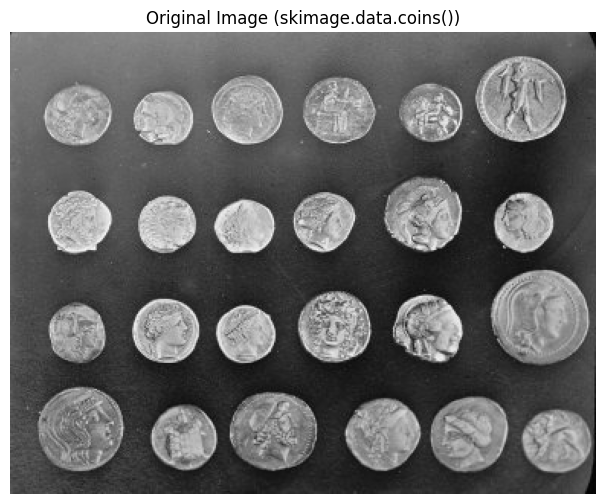

Citra berhasil dimuat dan ditampilkan dari skimage.data.


In [27]:
import matplotlib.pyplot as plt
from skimage import io, color, filters, segmentation, data
from sklearn.cluster import KMeans
import numpy as np
from scipy import ndimage as ndi
import warnings
# Menghapus import requests dan BytesIO karena akan menggunakan citra lokal
# import requests
# from io import BytesIO

# Menggunakan citra 'coins' bawaan dari skimage.data untuk menghindari masalah unduhan dari internet
# (sebelumnya data.apple() tidak ditemukan)
image_internet = data.coins() # Menggunakan citra coins sebagai pengganti

try:
    # Tampilkan citra asli
    plt.figure(figsize=(8, 6))
    plt.imshow(image_internet, cmap=plt.cm.gray) # Menggunakan cmap gray karena coins adalah citra grayscale
    plt.title('Original Image (skimage.data.coins())')
    plt.axis('off')
    plt.show()

    # Konversi ke grayscale untuk metode yang memerlukannya
    # Citra coins sudah grayscale, jadi tidak perlu konversi lagi
    if image_internet.ndim == 3:
        image_gray = color.rgb2gray(image_internet)
    else:
        image_gray = image_internet

    print("Citra berhasil dimuat dan ditampilkan dari skimage.data.")

except Exception as e:
    print(f"Error saat memuat atau memproses citra lokal: {e}")
    image_internet = None
    image_gray = None

### Metode Segmentasi 1: Thresholding Otsu

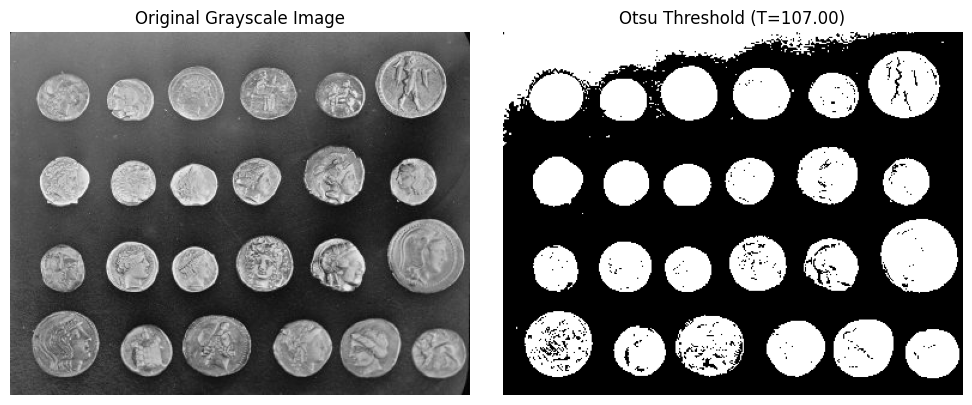

Nilai threshold Otsu untuk citra internet: 107.00


In [28]:
if image_gray is not None:
    # Otsu Thresholding
    thresh_otsu_internet = filters.threshold_otsu(image_gray)
    binary_otsu_internet = image_gray > thresh_otsu_internet

    fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharex=True, sharey=True)
    ax = axes.ravel()

    ax[0].imshow(image_gray, cmap=plt.cm.gray)
    ax[0].set_title('Original Grayscale Image')
    ax[0].axis('off')

    ax[1].imshow(binary_otsu_internet, cmap=plt.cm.gray)
    ax[1].set_title(f'Otsu Threshold (T={thresh_otsu_internet:.2f})')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Nilai threshold Otsu untuk citra internet: {thresh_otsu_internet:.2f}")
else:
    print("Citra tidak tersedia untuk Thresholding Otsu.")

### Metode Segmentasi 2: K-Means Clustering

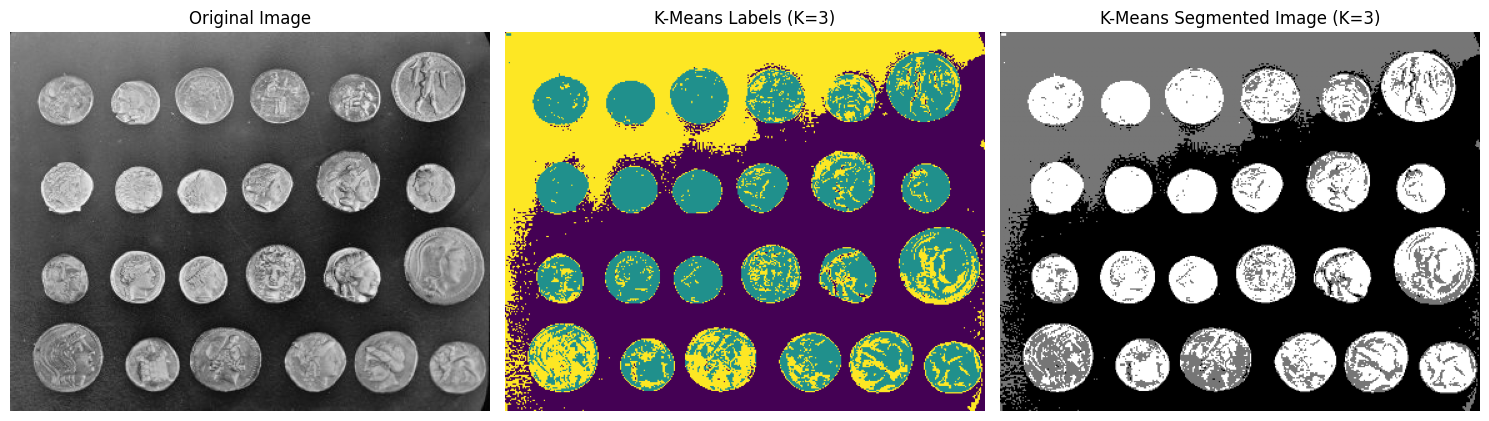

In [29]:
if image_internet is not None:
    # Konversi ke float dan reshape untuk K-Means
    image_float = image_internet.astype(float) / 255.0
    rows, cols = image_float.shape[0], image_float.shape[1]

    # Sesuaikan pixel_features berdasarkan dimensi citra
    if image_internet.ndim == 3: # Citra berwarna
        dims = image_float.shape[2]
        pixel_features = image_float.reshape(rows * cols, dims)
    else: # Citra grayscale
        pixel_features = image_float.reshape(rows * cols, 1) # Hanya 1 fitur (intensitas)

    # Terapkan K-Means (misal K=3 untuk latar belakang, objek, dan mungkin highlight/shadow)
    n_clusters_kmeans = 3
    kmeans_internet = KMeans(n_clusters=n_clusters_kmeans, random_state=0, n_init=10)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pixel_labels_kmeans = kmeans_internet.fit_predict(pixel_features)
    segmented_labels_kmeans = pixel_labels_kmeans.reshape(rows, cols)

    # Buat citra tersegmentasi dengan warna rata-rata klaster
    # Jika citra asli grayscale, hasil segmented_image_kmeans juga akan grayscale
    segmented_image_kmeans = np.zeros_like(pixel_features) # Inisialisasi dengan bentuk yang sama dengan pixel_features
    centers_kmeans = kmeans_internet.cluster_centers_
    for k_val in range(n_clusters_kmeans):
        mask_k_kmeans = (pixel_labels_kmeans == k_val)
        segmented_image_kmeans[mask_k_kmeans] = centers_kmeans[k_val]

    # Reshape kembali ke bentuk citra
    segmented_image_kmeans = segmented_image_kmeans.reshape(rows, cols, -1) # -1 akan otomatis menentukan dimensi terakhir

    # Jika outputnya 1 dimensi (grayscale), kita perlu menanganinya secara khusus untuk imshow
    if segmented_image_kmeans.shape[-1] == 1: # Jika 1 channel, imshow bisa menampilkannya
        segmented_image_kmeans = segmented_image_kmeans.squeeze()
        cmap_kmeans = plt.cm.gray # Gunakan colormap gray untuk hasil grayscale
    else: # Jika multi channel (warna)
        cmap_kmeans = None # imshow akan pakai default untuk warna

    fig, axes = plt.subplots(ncols=3, figsize=(15, 5), sharex=True, sharey=True)
    ax = axes.ravel()

    ax[0].imshow(image_internet, cmap=plt.cm.gray) # Pastikan original juga grayscale cmap
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(segmented_labels_kmeans, cmap='viridis') # Label bisa pakai viridis
    ax[1].set_title(f'K-Means Labels (K={n_clusters_kmeans})')
    ax[1].axis('off')

    ax[2].imshow(segmented_image_kmeans, cmap=cmap_kmeans)
    ax[2].set_title(f'K-Means Segmented Image (K={n_clusters_kmeans})')
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Citra tidak tersedia untuk K-Means Clustering.")

### Metode Segmentasi 3: Watershed Segmentation

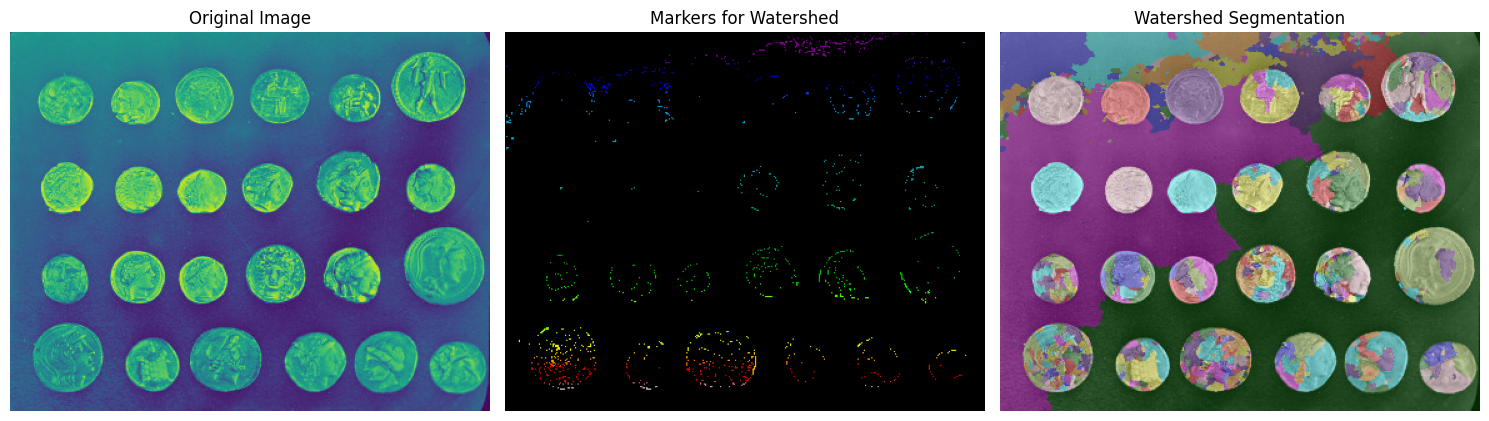

In [31]:
if image_gray is not None:
    # Hitung gradien citra (sebagai 'topografi')
    elevation_map_internet = filters.sobel(image_gray)

    # Buat markers dari citra biner (misalnya dari Otsu) atau distance transform
    # Menggunakan Otsu sebagai marker awal
    if 'binary_otsu_internet' in locals():
        markers_base = binary_otsu_internet
    else:
        # Fallback jika Otsu belum dijalankan atau gagal
        thresh_otsu_fallback = filters.threshold_otsu(image_gray)
        markers_base = image_gray > thresh_otsu_fallback

    # Invert image for distance transform if markers_base means foreground
    distance = ndi.distance_transform_edt(markers_base)
    from skimage.feature import peak_local_max # Import peak_local_max dari skimage.feature
    coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=markers_base)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers_watershed = ndi.label(mask)[0]

    # Terapkan algoritma Watershed
    # Perhatikan: watershed bekerja pada citra 'elevation_map' dan 'markers'
    labels_watershed = segmentation.watershed(elevation_map_internet, markers_watershed, mask=image_gray > 0.05) # mask untuk menghindari background noise

    # Warnai hasil segmentasi untuk visualisasi
    segmented_watershed_colored = color.label2rgb(labels_watershed, image=image_internet, bg_label=0)

    fig, axes = plt.subplots(ncols=3, figsize=(15, 5), sharex=True, sharey=True)
    ax = axes.ravel()

    ax[0].imshow(image_internet)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(markers_watershed, cmap=plt.cm.nipy_spectral)
    ax[1].set_title('Markers for Watershed')
    ax[1].axis('off')

    ax[2].imshow(segmented_watershed_colored)
    ax[2].set_title('Watershed Segmentation')
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Citra tidak tersedia untuk Watershed Segmentation.")

### Perbandingan dan Diskusi Hasil Segmentasi

Setelah menerapkan Otsu, K-Means, dan Watershed pada citra apel yang sederhana, kita dapat mengamati perbedaan dan efektivitas masing-masing metode:

1.  **Thresholding Otsu:**
    *   **Hasil:** Otsu adalah metode *global thresholding* yang mencari satu nilai ambang optimal untuk seluruh citra. Pada citra apel ini, yang memiliki latar belakang yang relatif seragam dan kontras yang jelas antara apel dan latar belakang, Otsu bekerja cukup baik dalam memisahkan apel dari latar belakang. Anda akan mendapatkan citra biner yang menunjukkan bentuk apel.
    *   **Kelebihan:** Simpel, cepat, dan efektif untuk citra dengan distribusi histogram bimodal yang jelas.
    *   **Kekurangan:** Tidak cocok untuk citra dengan pencahayaan tidak seragam atau latar belakang yang kompleks, karena hanya menghasilkan satu nilai ambang tunggal.

2.  **K-Means Clustering:**
    *   **Hasil:** K-Means mengelompokkan piksel berdasarkan kesamaan warna/intensitas. Dengan `K=3`, K-Means kemungkinan akan memisahkan apel, latar belakang, dan mungkin juga area highlight/shadow pada apel itu sendiri. Hasilnya bisa menghasilkan segmen yang lebih halus dan dapat menangani variasi warna dalam objek.
    *   **Kelebihan:** Dapat memisahkan objek berdasarkan warna, menghasilkan segmen yang lebih bervariasi secara semantik, dan tidak hanya biner. Baik untuk citra berwarna.
    *   **Kekurangan:** Jumlah `K` harus ditentukan sebelumnya, dan hasilnya bisa sangat bergantung pada inisialisasi klaster. Tidak mempertimbangkan informasi spasial.

3.  **Watershed Segmentation:**
    *   **Hasil:** Watershed adalah metode berbasis topologi yang baik untuk memisahkan objek-objek yang saling bersentuhan. Dengan menggunakan gradien citra sebagai 'peta elevasi' dan *markers* yang tepat (misalnya dari Otsu atau *distance transform*), Watershed dapat dengan presisi menentukan batas-batas objek. Pada citra apel, ini akan menghasilkan segmen yang sangat jelas pada batas apel.
    *   **Kelebihan:** Menghasilkan kontur segmen yang tertutup dan halus, sangat baik untuk memisahkan objek yang bersentuhan.
    *   **Kekurangan:** Sangat sensitif terhadap *noise* (dapat menyebabkan *over-segmentation*) dan membutuhkan *marker* yang baik. Penentuan *marker* yang efektif seringkali merupakan tantangan.

**Metode yang Paling Cocok untuk Citra Apel Pilihan Anda:**

Untuk citra apel sederhana dengan latar belakang polos dan kontras yang jelas, **Thresholding Otsu** adalah metode yang paling *efisien* dan **cukup memuaskan** untuk memisahkan apel dari latar belakang secara keseluruhan. Hasilnya akan menjadi segmentasi biner yang baik.

Namun, jika tujuannya adalah untuk memahami struktur internal apel (misalnya, area terang vs gelap, atau jika ada bagian yang rusak), **K-Means Clustering** akan memberikan hasil yang lebih detail dengan membagi apel ke dalam beberapa klaster warna/intensitas yang berbeda.

**Watershed Segmentation** akan menjadi pilihan terbaik jika Anda memiliki banyak apel yang saling bersentuhan dan ingin memisahkan masing-masing apel dengan batas yang sangat jelas dan tertutup, atau jika Anda membutuhkan segmentasi yang sangat presisi pada kontur objek.